In [1]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [3]:
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [6]:
print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [7]:
char_arr=np.array(['A','B','C','D','E'])
print(char_arr[[True,False,True,False,False]])

['A' 'C']


In [8]:
bream_smelt_indexes=(train_target=='Bream')|(train_target=='Smelt')
train_bream_smelt=train_scaled[bream_smelt_indexes]
target_bream_smelt=train_target[bream_smelt_indexes]

In [9]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [10]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [11]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [12]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [13]:
proba=lr.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [14]:
print(lr.coef_.shape,lr.intercept_.shape)

(7, 5) (7,)


In [15]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

In [16]:
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

In [17]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [18]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [19]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [20]:
sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.7983193277310925
0.775


In [21]:
import numpy as np
sc=SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes=np.unique(train_target)

In [22]:
for _ in range(0,300):
    sc.partial_fit(train_scaled,train_target,classes=classes)
    train_score.append(sc.score(train_scaled,train_target))
    test_score.append(sc.score(test_scaled,test_target))

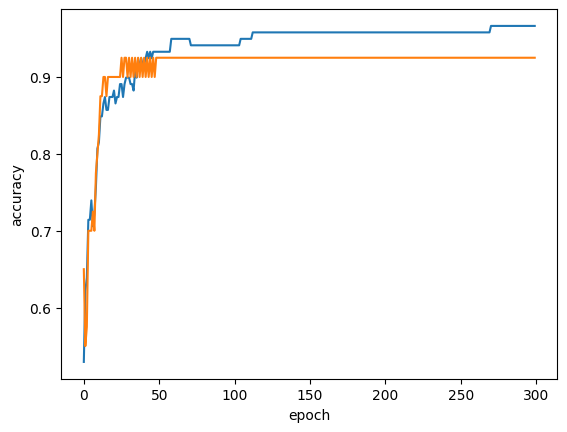

In [23]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [24]:
sc=SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [25]:
# 1번 과제
# 로지스틱 회귀 모델을 사용해 새로운 데이터셋에 대한 예측 결과 출력

# pandas: CSV 파일을 읽고 데이터프레임 형태로 다루기 위한 라이브러리
import pandas as pd

# numpy: 배열 계산을 쉽게 하기 위한 라이브러리
import numpy as np

# train_test_split: 데이터를 훈련 세트와 테스트 세트로 나누기 위한 함수
from sklearn.model_selection import train_test_split

# StandardScaler: 특성들의 스케일을 표준화하기 위한 클래스
from sklearn.preprocessing import StandardScaler

# LogisticRegression: 로지스틱 회귀 분류 모델
from sklearn.linear_model import LogisticRegression


# 1. 데이터셋 가져오기
# 생선 데이터를 CSV 파일로부터 읽어온다.
fish = pd.read_csv('http://bit.ly/fish_csv_data')


# 2. 입력 데이터와 타깃 데이터 분리
# 입력 데이터: 모델이 예측에 사용할 특성들
# Weight, Length, Diagonal, Height, Width 총 5개의 특성을 사용한다.
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]

# 타깃 데이터: 모델이 맞춰야 하는 정답
# Species는 생선의 종류를 의미한다.
fish_target = fish['Species']


# 3. 훈련 세트와 테스트 세트 분리
# 훈련 세트: 모델이 학습하는 데이터
# 테스트 세트: 학습하지 않은 데이터로 모델 성능을 평가하는 데이터
# random_state=42는 실행할 때마다 같은 방식으로 데이터가 나뉘도록 고정하는 역할을 한다.
train_input, test_input, train_target, test_target = train_test_split(
    fish_input,
    fish_target,
    random_state=42
)


# 4. 표준 정규화
# Logistic Regression은 특성 스케일에 영향을 받을 수 있으므로 표준화를 진행한다.
ss = StandardScaler()

# fit(): 훈련 세트의 평균과 표준편차를 계산한다.
ss.fit(train_input)

# transform(): 계산된 평균과 표준편차를 이용해 데이터를 표준화한다.
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)


# 5. 로지스틱 회귀 모델 훈련
# C=20: 규제 강도를 조절하는 값이다. 값이 클수록 규제가 약해진다.
# max_iter=1000: 반복 횟수를 늘려 모델이 충분히 학습되도록 한다.
lr = LogisticRegression(C=20, max_iter=1000)

# fit(): 훈련 데이터를 이용해 모델을 학습시킨다.
lr.fit(train_scaled, train_target)


# 6. 모델 성능 확인
# score(): 입력 데이터에 대한 모델의 정확도를 계산한다.
print("훈련 세트 정확도:", lr.score(train_scaled, train_target))
print("테스트 세트 정확도:", lr.score(test_scaled, test_target))


# 7. 새로운 데이터셋 생성
# 각 행은 하나의 생선 데이터를 의미한다.
# 특성 순서는 fish_input과 동일하게 Weight, Length, Diagonal, Height, Width 순서여야 한다.
test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])


# 8. 새로운 데이터도 같은 기준으로 표준화
# 모델은 표준화된 데이터로 학습했기 때문에,
# 새로운 데이터도 반드시 같은 StandardScaler로 변환해야 한다.
test_data_scaled = ss.transform(test_data)


# 9. 새로운 데이터 예측값 출력
# predict(): 각 생선 데이터가 어떤 Species로 분류되는지 출력한다.
predictions = lr.predict(test_data_scaled)

print("새로운 데이터 예측 결과:")
print(predictions)


# 10. 각 예측 결과에 대한 7종의 물고기별 확률 출력
# predict_proba(): 각 클래스에 속할 확률을 출력한다.
# 각 행의 확률 합은 1이다.
proba = lr.predict_proba(test_data_scaled)

print("클래스 목록:")
print(lr.classes_)

print("각 생선별 예측 확률:")
print(np.round(proba, decimals=3))


# 11. 예측 결과와 확률을 보기 좋게 출력
for i in range(len(test_data)):
    print()
    print(i + 1, "번째 새로운 데이터")
    print("예측 결과:", predictions[i])

    for fish_name, probability in zip(lr.classes_, proba[i]):
        print(f"{fish_name}: {probability:.3f}")

훈련 세트 정확도: 0.9327731092436975
테스트 세트 정확도: 0.925
새로운 데이터 예측 결과:
['Bream' 'Smelt' 'Pike' 'Perch' 'Whitefish']
클래스 목록:
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
각 생선별 예측 확률:
[[0.451 0.049 0.008 0.006 0.384 0.    0.102]
 [0.    0.002 0.048 0.    0.009 0.941 0.   ]
 [0.    0.    0.287 0.713 0.    0.    0.   ]
 [0.    0.013 0.512 0.001 0.461 0.002 0.011]
 [0.368 0.094 0.    0.    0.009 0.    0.528]]

1 번째 새로운 데이터
예측 결과: Bream
Bream: 0.451
Parkki: 0.049
Perch: 0.008
Pike: 0.006
Roach: 0.384
Smelt: 0.000
Whitefish: 0.102

2 번째 새로운 데이터
예측 결과: Smelt
Bream: 0.000
Parkki: 0.002
Perch: 0.048
Pike: 0.000
Roach: 0.009
Smelt: 0.941
Whitefish: 0.000

3 번째 새로운 데이터
예측 결과: Pike
Bream: 0.000
Parkki: 0.000
Perch: 0.287
Pike: 0.713
Roach: 0.000
Smelt: 0.000
Whitefish: 0.000

4 번째 새로운 데이터
예측 결과: Perch
Bream: 0.000
Parkki: 0.013
Perch: 0.512
Pike: 0.001
Roach: 0.461
Smelt: 0.002
Whitefish: 0.011

5 번째 새로운 데이터
예측 결과: Whitefish
Bream: 0.368
Parkki: 0.094
Perch: 0.000
Pike: 0.000
Roach: 0.009


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


에포크 10 모델
훈련 세트 정확도: 0.8067226890756303
테스트 세트 정확도: 0.875

에포크 300 모델
훈련 세트 정확도: 0.907563025210084
테스트 세트 정확도: 0.925


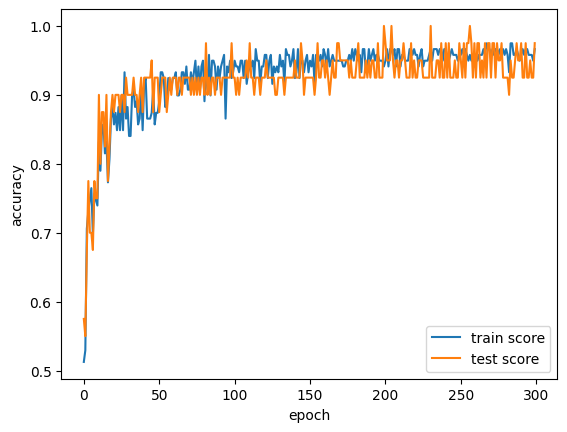


테스트 정확도가 가장 높은 에포크: 200
해당 에포크의 테스트 정확도: 1.0

선택한 에포크 모델
선택한 에포크 수: 200
훈련 세트 정확도: 0.9495798319327731
테스트 세트 정확도: 0.925

정확도 비교
에포크 10 테스트 정확도: 0.875
선택한 에포크 테스트 정확도: 0.925


In [26]:
# 2번 과제
# SGDClassifier 모델을 훈련시키고 최적의 에포크 값을 찾기

# pandas: CSV 파일을 읽기 위한 라이브러리
import pandas as pd

# numpy: 배열 계산을 위한 라이브러리
import numpy as np

# matplotlib: 그래프를 그리기 위한 라이브러리
import matplotlib.pyplot as plt

# train_test_split: 훈련 세트와 테스트 세트를 나누기 위한 함수
from sklearn.model_selection import train_test_split

# StandardScaler: 데이터 표준화를 위한 클래스
from sklearn.preprocessing import StandardScaler

# SGDClassifier: 확률적 경사 하강법을 사용하는 분류 모델
from sklearn.linear_model import SGDClassifier


# 1. 데이터셋 가져오기
# 생선 데이터를 CSV 파일로부터 읽어온다.
fish = pd.read_csv('http://bit.ly/fish_csv_data')


# 2. 입력 데이터와 타깃 데이터 분리
# 입력 데이터: 생선의 수치 특성
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]

# 타깃 데이터: 생선의 종류
fish_target = fish['Species']


# 3. 훈련 세트와 테스트 세트 분리
# 훈련 세트는 모델 학습에 사용하고, 테스트 세트는 성능 평가에 사용한다.
train_input, test_input, train_target, test_target = train_test_split(
    fish_input,
    fish_target,
    random_state=42
)


# 4. 표준 정규화
# SGDClassifier는 경사 하강법 기반 모델이므로 스케일 차이에 영향을 많이 받는다.
# 따라서 표준화를 해주는 것이 중요하다.
ss = StandardScaler()

# 훈련 세트를 기준으로 평균과 표준편차를 계산한다.
ss.fit(train_input)

# 훈련 세트와 테스트 세트를 같은 기준으로 변환한다.
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)


# 5. SGDClassifier 모델 훈련 - 에포크 10
# loss='hinge': 선형 SVM 방식의 손실 함수를 사용한다.
# max_iter=10: 전체 훈련 데이터를 10번 반복해서 학습한다.
# random_state=42: 실행 결과를 일정하게 유지한다.
sc_10 = SGDClassifier(
    loss='hinge',
    max_iter=10,
    random_state=42
)

# fit(): 모델을 훈련시킨다.
sc_10.fit(train_scaled, train_target)

# 에포크 10일 때의 정확도 출력
print("에포크 10 모델")
print("훈련 세트 정확도:", sc_10.score(train_scaled, train_target))
print("테스트 세트 정확도:", sc_10.score(test_scaled, test_target))


# 6. SGDClassifier 모델 훈련 - 에포크 300
# max_iter=300으로 설정하여 더 많이 반복 학습한다.
sc_300 = SGDClassifier(
    loss='hinge',
    max_iter=300,
    random_state=42
)

sc_300.fit(train_scaled, train_target)

print()
print("에포크 300 모델")
print("훈련 세트 정확도:", sc_300.score(train_scaled, train_target))
print("테스트 세트 정확도:", sc_300.score(test_scaled, test_target))


# 7. 매 에포크마다 훈련 점수와 테스트 점수 기록
# partial_fit()을 사용하면 모델을 한 번에 끝까지 학습하지 않고,
# 에포크마다 조금씩 이어서 학습할 수 있다.
sc = SGDClassifier(
    loss='hinge',
    random_state=42
)

# 에포크마다 훈련 정확도와 테스트 정확도를 저장할 리스트
train_score = []
test_score = []

# partial_fit()을 처음 사용할 때는 전체 클래스 목록을 알려줘야 한다.
classes = np.unique(train_target)


# 0부터 299까지 총 300번 반복한다.
# 반복 1번이 에포크 1번과 비슷한 의미를 가진다.
for epoch in range(300):
    # partial_fit(): 모델을 한 번씩 추가 학습시킨다.
    sc.partial_fit(train_scaled, train_target, classes=classes)

    # 현재 에포크에서의 훈련 세트 정확도 저장
    train_score.append(sc.score(train_scaled, train_target))

    # 현재 에포크에서의 테스트 세트 정확도 저장
    test_score.append(sc.score(test_scaled, test_target))


# 8. 에포크를 x축, 정확도를 y축으로 하는 그래프 그리기
plt.plot(train_score, label='train score')
plt.plot(test_score, label='test score')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


# 9. 눈으로 보고 적절한 에포크 수 찾기
# 아래 코드는 테스트 정확도가 가장 높은 에포크를 자동으로 찾는다.
# 그래프를 눈으로 보는 것과 함께 참고용으로 사용하면 된다.
best_epoch = np.argmax(test_score) + 1
best_test_score = np.max(test_score)

print()
print("테스트 정확도가 가장 높은 에포크:", best_epoch)
print("해당 에포크의 테스트 정확도:", best_test_score)


# 10. 선택한 에포크 수로 최종 모델 훈련
# 과제에서는 그래프를 보고 직접 적절한 값을 선택하면 된다.
# 여기서는 테스트 정확도가 가장 높았던 에포크를 사용한다.
sc_best = SGDClassifier(
    loss='hinge',
    max_iter=best_epoch,
    tol=None,
    random_state=42
)

sc_best.fit(train_scaled, train_target)

print()
print("선택한 에포크 모델")
print("선택한 에포크 수:", best_epoch)
print("훈련 세트 정확도:", sc_best.score(train_scaled, train_target))
print("테스트 세트 정확도:", sc_best.score(test_scaled, test_target))


# 11. 에포크 10 모델과 선택한 에포크 모델 정확도 비교
print()
print("정확도 비교")
print("에포크 10 테스트 정확도:", sc_10.score(test_scaled, test_target))
print("선택한 에포크 테스트 정확도:", sc_best.score(test_scaled, test_target))